# Social Data Analysis: Generalities, Complex Networks and Node-Centric Metrics

In this practical work, we will first check  :
 - if a network satisfies the 3 constraints to be considered as a complex network and 
 - then, we will determine how important nodes are within this network. 

The library we will use for handling networks is networkx

## First, let's install the expecting libraries 
(not necessary if you are certain these libs are installed on your system)

In [ ]:
%pip install pandas
%pip install networkx
%pip install seaborn
%pip install powerlaw
%pip install pickledb

## Second, let's import the useful packages
You can avoid the first line if you are not using a Jupyter notebook. This line enables the visualization to be displayed in the notebook.

In [33]:
%matplotlib inline

import networkx as nx
import pandas as pd
import pickle
import math
import powerlaw
import numpy as np
import seaborn as sns
from scipy import stats
import matplotlib as mpl
import matplotlib.pyplot as plt

#### **Good, if you have not encounter any problems, we can start working now!**

#### First download the dataset (on Moodle)

In [34]:
# Obviously, you must replace the path below by the appropriate path
pathData_1 = "data/airports.net"
pathData_2 = "data/collaboration.edgelist.txt"
pathData_3 = "data/lesmis.gml"

:::
 - Then, navigate through the documentation of the networkx package and find how to load networks in the pajek format
 - Note that the graph should be __directed__.

      - TIP: to create a directed simple graph after loading the pajek network, you must use the follwing instruction 
          - `g = nx.DiGraph(g)` where `g` is the loaded pajek network.
::: 

:::
**Définition**   

- `Weakly connected` : Un graphe dirigé (ou digraphe) est considéré comme weakly connected si, en remplaçant toutes les arêtes dirigées par des arêtes non dirigées, le graphe résultant est un graphe non dirigé connecté. Cela signifie qu'il existe un chemin entre chaque paire de sommets dans le graphe, mais ce chemin peut ne pas suivre la direction des arêtes originales. 

- `Strongly connected` : Un graphe orienté est fortement connecté si pour toute paire de sommets distincts, il existe un chemin orienté allant du premier sommet au second et un chemin orienté allant du second sommet au premier. Cela implique que le graphe est non seulement faiblement connecté mais aussi que les chemins entre les sommets respectent l'orientation des arêtes.
     
:::             




In [35]:
def get_GraphFile_information(GD,node_size=40):
    # Check weak connectivity
    if nx.is_weakly_connected(GD):
        print("The graph is weakly connected.")
    else:
        print("The graph is not weakly connected.")
    # Number of weakly connected components
    num_wcc = nx.number_weakly_connected_components(GD)
    print(f"Number of weakly connected components: {num_wcc}")
    # Generate weakly connected components
    wcc = list(nx.weakly_connected_components(GD))
    print("Weakly connected components:", wcc)

    print("Ordre : ", nx.number_of_nodes(GD), "sommets")
    print("Taille : ", nx.number_of_edges(GD), "liens")
    print("Réseau orienté ?", nx.is_directed(GD))
    print("attribut des liens : ", list(list(GD.edges(data=True))[0][-1].keys()))
    print("attribut des sommets : ", list(list(GD.nodes(data=True))[0][-1].keys()))

    fig = plt.figure(figsize = (5, 5))
    nx.draw(GD,node_size=node_size, node_color='green', linewidths=0.01)
    plt.show()
    return GD

The graph is not weakly connected.
Number of weakly connected components: 567
Weakly connected components: [{'11722', '5707', '2919', '15060', '9747', '22552', '12230', '11984', '15730', '918', '713', '22334', '10011', '3285', '7200', '47', '16308', '6259', '19527', '15766', '21468', '9022', '156', '9883', '8372', '3281', '12011', '20646', '11258', '7386', '13697', '21751', '6114', '237', '20807', '21353', '15923', '3762', '10164', '2804', '2056', '5903', '15625', '13945', '1028', '3713', '6376', '17275', '18078', '5385', '9541', '14335', '14587', '7458', '21173', '14872', '17932', '612', '641', '18654', '7873', '18877', '20959', '8905', '2846', '11506', '13523', '15635', '20844', '10146', '2620', '16721', '20992', '12161', '1084', '11102', '4756', '16191', '13414', '16275', '14018', '9756', '15582', '6672', '19662', '6413', '50', '17755', '21501', '4884', '999', '22371', '12972', '13443', '15025', '17294', '4103', '19004', '922', '15739', '8287', '5058', '7184', '2718', '12894', '2203

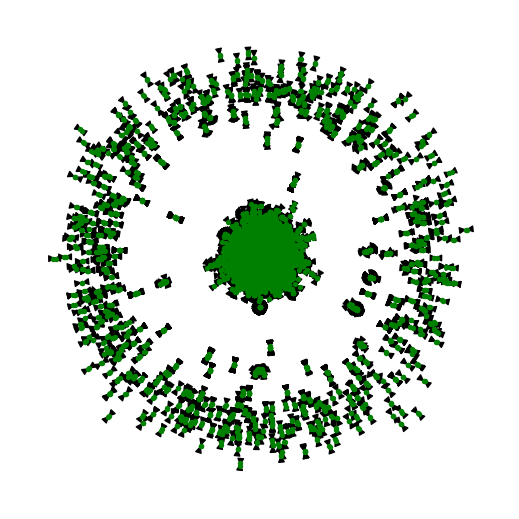

In [36]:
# read the edge list file

G = nx.DiGraph(nx.read_edgelist(pathData_2))
G2_edgl = get_GraphFile_information(G,15)

The graph is weakly connected.
Number of weakly connected components: 1
Weakly connected components: [{'Favourite', 'Cravatte', 'Labarre', 'Gillenormand', 'CountessDeLo', 'Gribier', 'MmePontmercy', 'Anzelma', 'Gueulemer', 'MotherInnocent', 'Fameuil', 'Champtercier', 'Brevet', 'Grantaire', 'Magnon', 'Woman2', 'Cosette', 'Montparnasse', 'Fantine', 'Valjean', 'Child1', 'MlleVaubois', 'MmeDeR', 'MotherPlutarch', 'MlleGillenormand', 'Jondrette', 'Eponine', 'Zephine', 'Courfeyrac', 'Bamatabois', 'Myriel', 'MmeBurgon', 'Champmathieu', 'Babet', 'Woman1', 'Child2', 'Toussaint', 'Perpetue', 'OldMan', 'Javert', 'Brujon', 'Scaufflaire', 'Gervais', 'Claquesous', 'Pontmercy', 'Count', 'Bahorel', 'Napoleon', 'Marguerite', 'MmeMagloire', 'Listolier', 'Dahlia', 'MlleBaptistine', 'Thenardier', 'Isabeau', 'Joly', 'Enjolras', 'MmeThenardier', 'Blacheville', 'Chenildieu', 'Combeferre', 'Prouvaire', 'LtGillenormand', 'Simplice', 'MmeHucheloup', 'Bossuet', 'Cochepaille', 'Geborand', 'Mabeuf', 'Marius', 'Baro

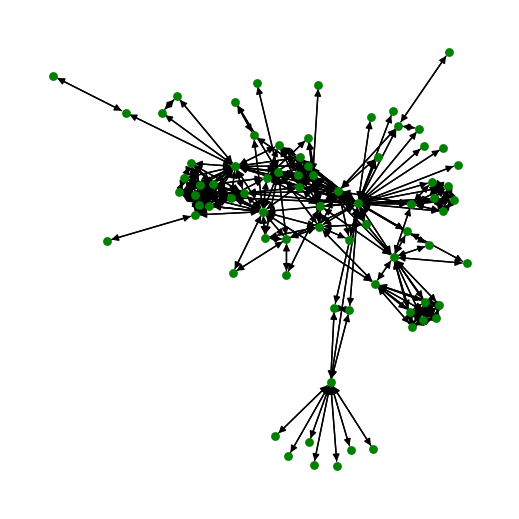

In [37]:
# Read the GML file
G = nx.DiGraph(nx.read_gml(pathData_3))
G3_gml = get_GraphFile_information(G)

The graph is weakly connected.
Number of weakly connected components: 1
Weakly connected components: [{'Lambert-St Louis Intl', 'New Hanover Intll', 'Eastern Oregon Regional At Pen', 'San Antonio Intl', 'Billings Logan Intl', 'Mercedita', 'Sarasota/Bradenton Intl', 'Greenbrier Valley', 'Newark Intl', 'Dane County Regional-Truax Fie', 'Sonoma County', 'Will Rogers World', 'Pensacola Regional', 'Norfolk Intl', 'William B. Heilig Field', 'West Tinian', 'Tuluksak', 'Aspen-Pitkin Co/Sardy Field', 'Portland Intl', 'Roanoke Regional/Woodrum Field', 'Eagle County Regional', 'Babelthuap/Koror', 'Mammoth Lakes', 'Worcester Muni', 'Merle K (Mudhole) Smith', 'Cincinnati/Northern Kentucky I', 'Burlington Intl', 'Waco Regional', 'Kahului', 'Harrisburg Intll', 'Walla Walla Regional', 'Columbia Metropolitan', 'Grand Forks Afb', 'Cherry Capital', 'Modesto City-County--Harry Sha', 'Birmingham Intl', 'King Salmon', 'La Guardia', 'Cedar Rapids Muni', 'Joplin Regional', 'Chico Muni', 'Bradley Intl', 'Lovel

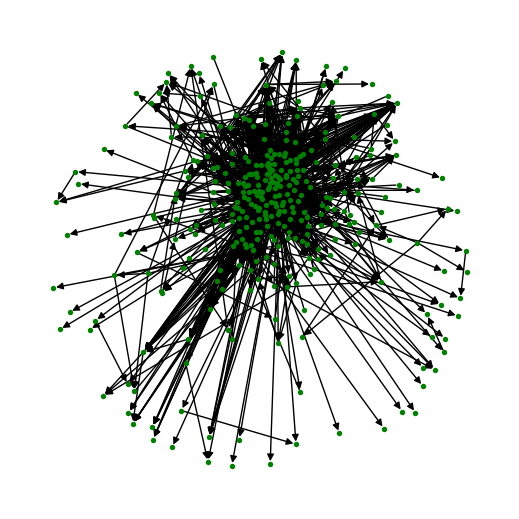

In [38]:
# Read the pajek file   
G = nx.DiGraph(nx.read_pajek(pathData_1))
G1_net = get_GraphFile_information(G,15)

# Check the complex network properties
## Long-tail distribution

### Plot the degree distribution of the graph
  1. Calculate and store the degree of each node
      - The number of node'neighbours represents its degree $d_{v}= |N(v)|$
      - in-degree dv in and out-degree dvout :
          - incoming neighbours $N_{in}(v) d_v^{in}$ : number of edges pointing to node v
          - outcoming neighbours $N_{out}(v) d_v^{out}$ : number of edges pointing away from node v



2. Convert the result (a dict) into a Pandas object, a Series

In [39]:
def make_dataframe(GD):
#df1 = pd.DataFrame(GD, columns=['ID', 'Node name']) 
    df2 = pd.DataFrame(GD.degree(), columns=['ID', 'degree neighb']) 
    df3 = pd.DataFrame(GD.in_degree() , columns=['ID', 'degree in']) 
    df4 = pd.DataFrame(GD.out_degree() , columns=['ID', 'degree out']) 
    df5 = pd.DataFrame(GD.in_degree(weight = "weight") , columns=['ID', 'weight in']) 
    df6 = pd.DataFrame(GD.out_degree(weight = "weight") , columns=['ID', 'weight out']) 
    # Combinez les listes de tuples en utilisant zip
    df = pd.merge(df2, df3, on='ID')
    df = pd.merge(df, df4, on='ID')
    df = pd.merge(df, df5, on='ID')
    df = pd.merge(df, df6, on='ID')
    return df


def display_features(GD):
    #  Calculate the degree distribution
    degrees = [degree for node, degree in GD.degree()]
    print(f'Node number : {GD.number_of_nodes()}')
    print(f'Node Name : {GD}')
    print(f'Degrees : {degrees}')
    print(f'Degree number : {GD.degree()}')
    print(f'Incoming neighbors number : {GD.in_degree()}')
    print(f'Outcoming neighbors number : {GD.out_degree()}')
    print(f'Incoming neighbors weight number : {GD.in_degree(weight = "weight")}')
    print(f'Outcoming neighbors weight number : {GD.out_degree(weight = "weight")}')
    print(f'To get normalized values : {nx.degree_centrality(GD)}')

In [40]:
make_dataframe(G1_net).head(10).style

,ID,degree neighb,degree in,degree out,weight in,weight out
0,Wiley Post-Will Rogers Mem,3,0,3,0.000000,0.222900
1,Deadhorse,3,1,2,0.043600,0.138100
2,Ralph Wien Memorial,2,0,2,0.000000,0.111200
3,Fairbanks Intl,5,2,3,0.128200,0.338900
4,Nome,2,1,1,0.026900,0.084900
5,St Mary's,3,0,3,0.000000,0.102300
6,Aniak,3,1,2,0.019700,0.062800
7,Anchorage Intl,29,7,22,0.512000,3.800200
8,Tuluksak,4,0,4,0.000000,0.014200
9,Akiachak,4,1,3,0.003000,0.004400


In [41]:
make_dataframe(G2_edgl).head(10).style

,ID,degree neighb,degree in,degree out,weight in,weight out
0,0,6,3,3,3,3
1,1680,16,8,8,8,8
2,6918,10,5,5,5,5
3,19642,10,5,5,5,5
4,1820,10,5,5,5,5
5,2438,44,22,22,22,22
6,10014,10,5,5,5,5
7,15750,8,4,4,4,4
8,16763,166,83,83,83,83
9,1,16,8,8,8,8


In [43]:
make_dataframe(G3_gml).head(10).style

,ID,degree neighb,degree in,degree out,weight in,weight out
0,Myriel,20,10,10,10,10
1,Napoleon,2,1,1,1,1
2,MlleBaptistine,6,3,3,3,3
3,MmeMagloire,6,3,3,3,3
4,CountessDeLo,2,1,1,1,1
5,Geborand,2,1,1,1,1
6,Champtercier,2,1,1,1,1
7,Cravatte,2,1,1,1,1
8,Count,2,1,1,1,1
9,OldMan,2,1,1,1,1


3. Use the seaborn `distplot` function to plot the degree distribution.    
     - Probability that a randomly chosen node has degree d : 
        - $\pi(d)=\{d_k, k=1...n \} \text{ with } d_k = \frac{n_k}{n}$  ($n_k $ : number of nodes with $k$ degrees).
  
   Check the documentation to set the parameters as follows:     
      - 20 bins and no gaussian kernel density estimate. 
         - Note that you must use the `plt.show()` instruction afterward to visualize the result.

   Check if the graph satisfies the power-law degree property
      - Modify the call to the `distplot` function to graphically check if the degree distribution fits a power-law distribution. 
         - To do so, you should set the `fit` parameter to `stats.powerlaw`.
         

In [44]:

def display_degree_distribution(GD):
    degree_sequence = sorted((d for n, d in GD.degree()), reverse=False)
    data=pd.DataFrame(degree_sequence, columns=['Degree distribution'])
    #  Create the distplot
    fig, ax = plt.subplots(figsize=(4, 3))
    # Créer le plot using histplot
    sns.histplot(data, ax=ax, color='blue', alpha=0.5, label='Degree distribution', bins=20, kde=False)
    # Générer les valeurs pour la courbe de puissance ajustée
    x = np.linspace(data.min(), data.max(), 100)
    # Ajuster les données à une distribution de puissance
    params = stats.powerlaw.fit(data, floc=0)
    y = stats.powerlaw.pdf(x, *params)
    # Tracer la courbe de puissance ajustée
    ax.plot(x, y * len(data) / np.sum(y), 'r-', lw=2, label='Power Law Fit')
    #ax.loglog(x, y * len(data) / np.sum(y), 'r-', lw=2, label='Power Law Fit')
    # Définir la taille des caractères des labels d'axes
    ax.set_xlabel('Degree', fontsize=10)
    ax.set_ylabel('Fréquency', fontsize=10)
    # Définir la taille des caractères des étiquettes de ticks
    ax.tick_params(axis='both', which='major', labelsize=10)
    # Ajouter une légende
    ax.legend()
    # Show the plot
    plt.show()

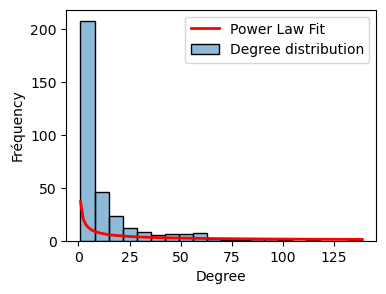

In [45]:
display_degree_distribution(G1_net)

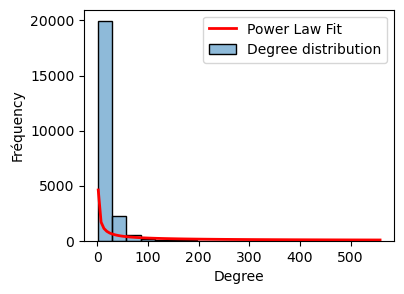

In [48]:
display_degree_distribution(G2_edgl)

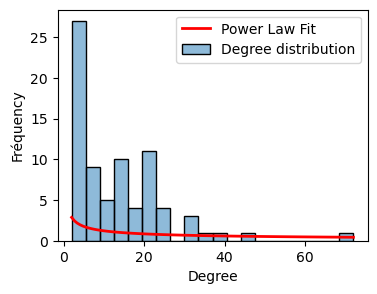

In [49]:
display_degree_distribution(G3_gml)

 - **Conclude** : This approach allows you to check graphically if the distribution of degrees follows a power law by displaying the data and the corresponding adjustment curve.
      - If $y=x^{-\alpha}$ the curve in logarithmic scale will be a straight line with a slope of $-\alpha$.
      - As expected the graphics is a power-law distribution, as observed in red.

## Small-world hypothesis
We now want to check if this network satisfies the small-world hypothesis. 
 - Calculate the average shortest path length 
 $a =\sum_{\substack{s,t \in V \\ s\neq t}} \frac{d(s, t)}{n(n-1)}$ 
   - where $V$ is the set of nodes in $G$, $d(s, t)$ is the shortest path from $s$ to $t$, and n is the number of nodes in $G$.
  

In [50]:
def Average_Shortest_Path_Length(GD):
    if GD.number_of_nodes() <= 1:
        return 0  # Handle the case where the graph has one or zero nodes

    all_pairs_lengths = nx.all_pairs_shortest_path_length(GD)

    total_length = 0
    total_pairs = 0

    for source_node, lengths in all_pairs_lengths:
        for target_node, length in lengths.items():
            if source_node != target_node:  # Avoid self-loops and duplicate calculations
                if length != float('inf'):  # Check if there is a path
                    total_length += length
                    total_pairs += 1

    if total_pairs == 0:
        return 0  # No paths found between any pairs of nodes
    else:
        avg_shrt_pth_lnth = total_length / total_pairs
        return avg_shrt_pth_lnth

 - In order to use nx.average_shortest_path_length the graph must be strongly conneted

In [51]:
print(f' The average shortest path length G1 : {Average_Shortest_Path_Length(G1_net)} ')

 The average shortest path length G1 : 2.5639775322510956 


In [52]:
print(f' The average shortest path length G2 : {Average_Shortest_Path_Length(G2_edgl)} ')

 The average shortest path length G2 : 5.3521018968755385 


In [53]:
print(f' The average shortest path length G0 : {Average_Shortest_Path_Length(G3_gml)} ')

 The average shortest path length G0 : 2.6411483253588517 


 :::
 
 **Conclude if this network satisfies the small world hypothesis**    

:::

:::

   - *Six degree separation related to the "small world" hypothesis*  :      
        - «Any two people selected randomly from the population are on average separated no more that by six intermediate connections»     
    
Returns the small-world coefficient (sigma) of the given graph.
 - The small-world coefficient is defined as: $\large \sigma = \frac{\frac{C}{Cr}}{\frac{L}{Lr}}$
    -  where C and L are respectively the average clustering coefficient and average shortest path length of G. 
    - Cr and Lr are respectively the average clustering coefficient and average shortest path length of an equivalent random graph.
    - A graph is commonly classified as small-world if $\sigma > 1$.

    Calculate the normalised shortest path $\lambda := \frac{𝐿}{𝐿_r}. \text{  and  } \gamma:=\frac{𝐶}{𝐶_r}$.
    
    If $\lambda$ and $\gamma$ fulfil certain criteria (e.g., $\lambda \approxeq 1$ and $\gamma > 1$), call the network a small-world network.

:::

:::

**Check the strong community structure**    

To check how string is the community structure in this network, we will apply the following methodology:
   - Use `gnm_random_graph` to generate a random graph having the same number of vertices and edges than the studied network
   - Calculate the average clustering on both networks
   - Conclude 

:::   

In [54]:
def Sigma_SmallWorld(GD):
    C = nx.average_clustering(GD)
    #print(f'Average Clustering Coefficient C = {C} ')
    L = Average_Shortest_Path_Length(GD)
    #print(f'The average shortest path length L = {L}') 
    # Generate an equivalent random graph
    Gr = nx.gnm_random_graph(GD.number_of_nodes(), GD.number_of_edges(), seed=67, directed=True)
    # Calculate Cr (average clustering coefficient of the random graph)
    Cr = nx.average_clustering(Gr)
    #print(f'Average Clustering Coefficient of Random equivalent Graph Cr = {Cr}')
    Lr = Average_Shortest_Path_Length(Gr)
    #print(f'Average Clustering Coefficient for random equivalent graph Lr = {Lr} ')
    return (L/Lr), (C/Cr), ((C/Cr) / (L/Lr))

In [ ]:
nx.smallworld(G1_net)
nx.smallworld(G2_edgl)
nx.smallworld(G3_gml)

In [55]:
lambd, gamm, sigm = Sigma_SmallWorld(G1_net)
print(f'\n G0 Lambda = L/Lr  = {lambd} ;  Gamma = C/Cr = {gamm} ; Sigma  = Gamma/Lambda  ={sigm} ')


 G0 Lambda = L/Lr  = 0.7740220222110968 ;  Gamma = C/Cr = 16.14244022646452 ; Sigma  = Gamma/Lambda  =20.855272541666828 


In [56]:
lambd, gamm, sigm = Sigma_SmallWorld(G2_edgl)
print(f'\n G1 Lambda = L/Lr  = {lambd} ;  Gamma = C/Cr = {gamm} ; Sigma  = Gamma/Lambda  ={sigm} ')


 G1 Lambda = L/Lr  = 1.060882062176165 ;  Gamma = C/Cr = 1847.1713061273674 ; Sigma  = Gamma/Lambda  =1741.1655564599744 


In [57]:
lambd, gamm, sigm = Sigma_SmallWorld(G3_gml)
print(f'\n G2 Lambda = L/Lr  = {lambd} ;  Gamma = C/Cr = {gamm} ; Sigma  = Gamma/Lambda  ={sigm} ')


 G2 Lambda = L/Lr  = 1.058585297846973 ;  Gamma = C/Cr = 6.585952393673091 ; Sigma  = Gamma/Lambda  =6.2214659575077 


:::

- A graph is commonly classified as small-world if $\sigma > 1$.
  -  Calculate the normalised shortest path $\lambda := \frac{𝐿}{𝐿_r}. \text{  and  } \gamma:=\frac{𝐶}{𝐶_r}$.
  - If $\lambda$ and $\gamma$ fulfil certain criteria (e.g., $\lambda \approxeq 1$ and $\gamma > 1$), call the network a small-world network.

:::

# Node-Centric Metrics
We will now focus on the relative importance of vertices within the network.    
Luckily, many centrality metrics are implemented in networkx.

## Centrality Metrics
Have a look to the package documentation and calculate the following centralities:
  1. **Degree**   
      - The degree centrality for a node v is the fraction of nodes it is connected to.
      - The in-degree centrality for a node v is the fraction of nodes its incoming edges are connected to.
      - The out-degree centrality for a node v is the fraction of nodes its outgoing edges are connected to.

  - **Ajouter _centrality à la fonction utilisée permet d’obtenir les valeurs normalisées.**

In [58]:
def degree_centrality(grph, *args, **kwargs):
    return nx.degree_centrality(grph)

def centrality_function(f, grph) : 
    # Calculate degree centrality
    degree_centrality = f(grph)
    # Get the minimum and maximum degree centrality values
    min_degree = min(degree_centrality.values())
    max_degree = max(degree_centrality.values())# Create a colormap
    cmap = mpl.colormaps['turbo']
    # Normalize the degree centrality values
    norm = mpl.colors.Normalize(vmin=min_degree, vmax=max_degree)
    # Map degree centrality to colors
    node_colors = [cmap(norm(degree)) for degree in degree_centrality.values()]
    # Plot the graph
    pos = nx.spring_layout(grph)
    # Calculate node sizes based on degree centrality
    node_sizes = [int(degree * 1000) for degree in degree_centrality.values()]
    # Plot the graph with varying node sizes
    plt.figure(figsize=(10, 10))
    nx.draw_networkx_nodes(grph, pos, node_color=node_colors, node_size=node_sizes)
    nx.draw_networkx_edges(grph, pos, width=0.1, edge_color='gray')
    nx.draw_networkx_labels(grph, pos, font_size=1)
    plt.show()

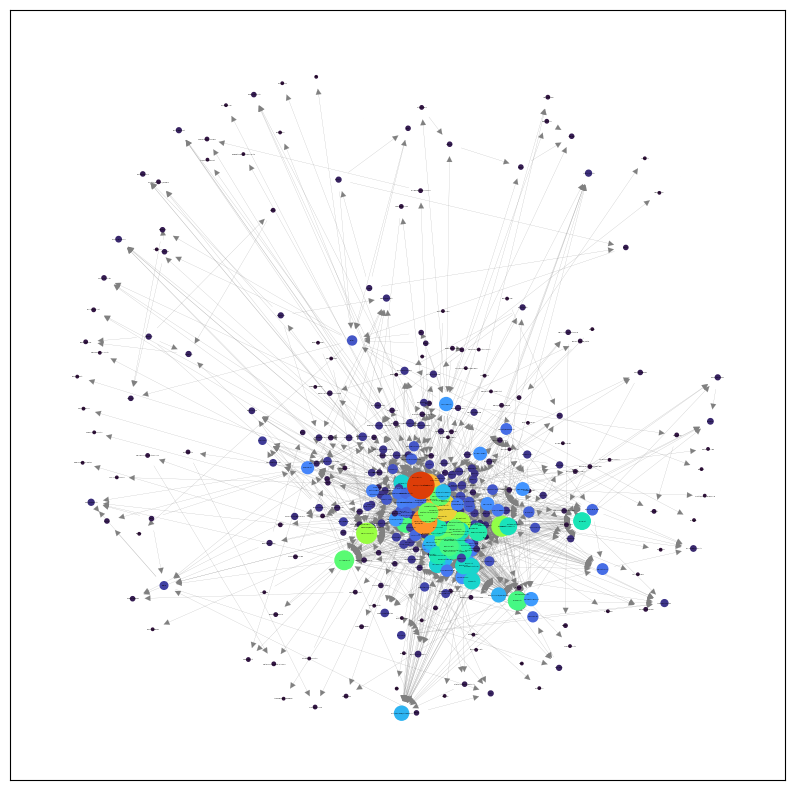

[('Wiley Post-Will Rogers Mem', 0.00906344410876133),
 ('Deadhorse', 0.00906344410876133),
 ('Ralph Wien Memorial', 0.006042296072507553),
 ('Fairbanks Intl', 0.015105740181268881),
 ('Nome', 0.006042296072507553),
 ("St Mary's", 0.00906344410876133),
 ('Aniak', 0.00906344410876133),
 ('Anchorage Intl', 0.08761329305135952),
 ('Tuluksak', 0.012084592145015106),
 ('Akiachak', 0.012084592145015106)]

In [60]:
centrality_function(degree_centrality, G1_net)
# Calculate degree centrality
list(nx.degree_centrality(G1_net).items())[:10]

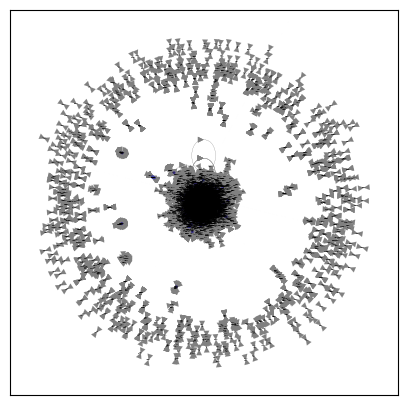

[('0', 0.15622474389421714),
 ('1680', 0.1880289729975711),
 ('6918', 0.17287783721244188),
 ('19642', 0.17287783721244188),
 ('1820', 0.18396280875812385),
 ('2438', 0.20897264634209198),
 ('10014', 0.18396280875812385),
 ('15750', 0.172876322241867),
 ('16763', 0.2273191265568852),
 ('1', 0.18996452276390655)]

In [44]:
centrality_function(degree_centrality, G2_edgl)
# Calculate degree centrality
list(nx.closeness_centrality(G2_edgl).items())[:10]

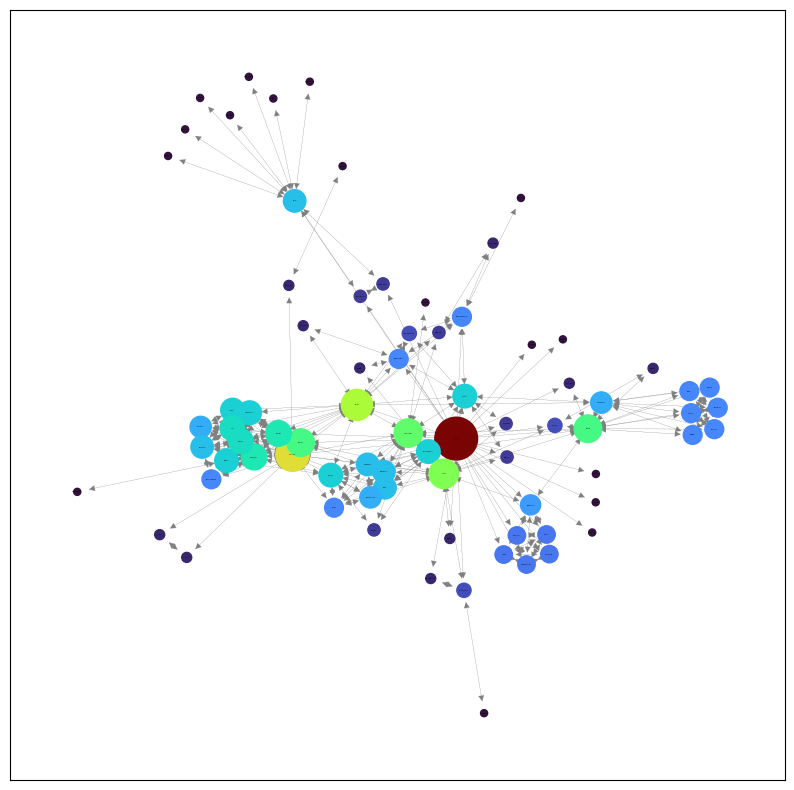

[('Myriel', 0.4293785310734463),
 ('Napoleon', 0.30158730158730157),
 ('MlleBaptistine', 0.41304347826086957),
 ('MmeMagloire', 0.41304347826086957),
 ('CountessDeLo', 0.30158730158730157),
 ('Geborand', 0.30158730158730157),
 ('Champtercier', 0.30158730158730157),
 ('Cravatte', 0.30158730158730157),
 ('Count', 0.30158730158730157),
 ('OldMan', 0.30158730158730157)]

In [64]:
centrality_function(degree_centrality, G3_gml)
# Calculate degree centrality
list(nx.closeness_centrality(G3_gml).items())[:10]

  2. **Closeness centrality**     
  How close are the other nodes :    
  - Close nodes $\overline{l_i}$ are expected to have a smaller average shortest path length to other nodes
    - $\large C_c(i) = \frac{1}{\overline{l_i}} \text { avec } \overline{l_i} = \frac{1}{n-1}\sum_{k \ne i}l_{ik}$

  - Closeness centrality of a node $u$ is the reciprocal of the average shortest path distance to $u$ over all $(n-1)$ reachable nodes. 
      - $\large C(u) = \frac{n - 1}{\sum_{v=1}^{n-1} d(v, u)},$


In [65]:
def closeness_centrality(grph):
    return nx.closeness_centrality(grph)

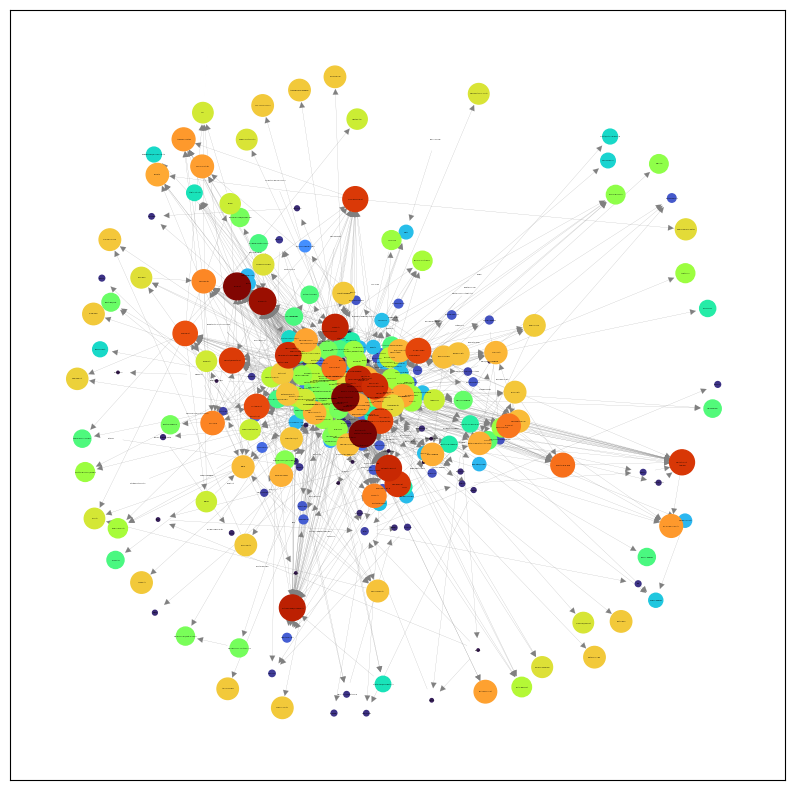

[('Wiley Post-Will Rogers Mem', 0.0),
 ('Deadhorse', 0.0030211480362537764),
 ('Ralph Wien Memorial', 0.0),
 ('Fairbanks Intl', 0.006042296072507553),
 ('Nome', 0.0030211480362537764),
 ("St Mary's", 0.0),
 ('Aniak', 0.0030211480362537764),
 ('Anchorage Intl', 0.021148036253776436),
 ('Tuluksak', 0.0),
 ('Akiachak', 0.0030211480362537764)]

In [66]:
centrality_function(closeness_centrality, G1_net)
# proximité
list(nx.closeness_centrality(G1_net).items())[:10]

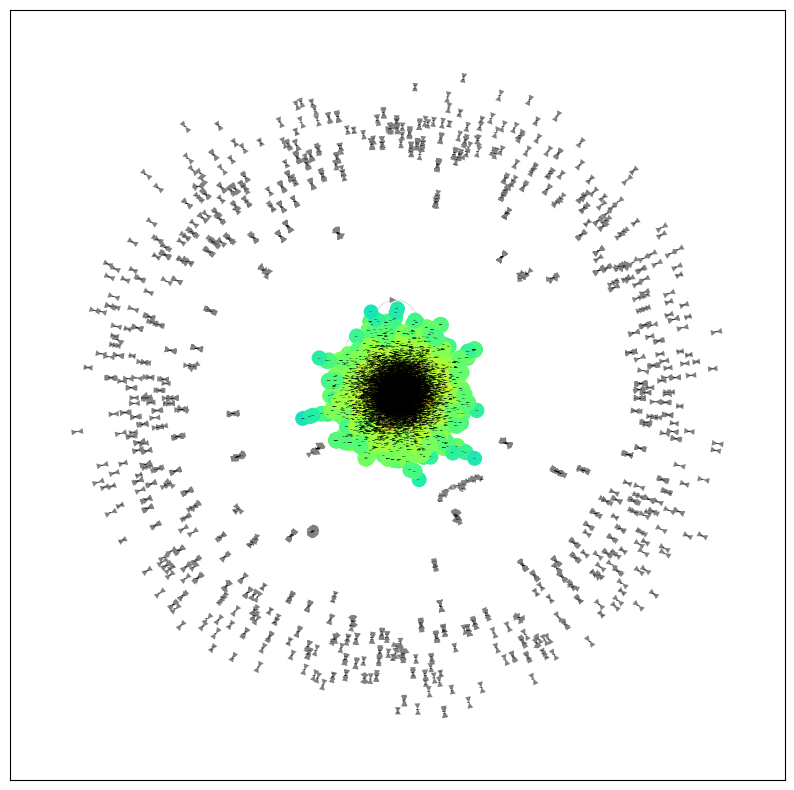

[('0', 0.15622474389421714),
 ('1680', 0.1880289729975711),
 ('6918', 0.17287783721244188),
 ('19642', 0.17287783721244188),
 ('1820', 0.18396280875812385),
 ('2438', 0.20897264634209198),
 ('10014', 0.18396280875812385),
 ('15750', 0.172876322241867),
 ('16763', 0.2273191265568852),
 ('1', 0.18996452276390655)]

In [42]:
centrality_function(closeness_centrality, G2_edgl)
# proximité
list(nx.closeness_centrality(G2_edgl).items())[:10]

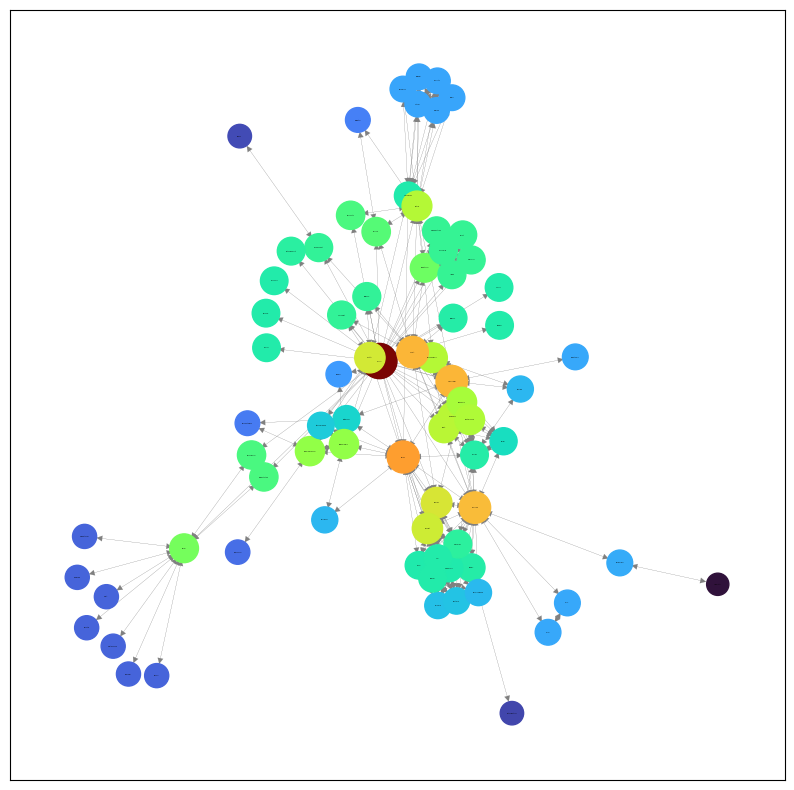

[('Myriel', 0.4293785310734463),
 ('Napoleon', 0.30158730158730157),
 ('MlleBaptistine', 0.41304347826086957),
 ('MmeMagloire', 0.41304347826086957),
 ('CountessDeLo', 0.30158730158730157),
 ('Geborand', 0.30158730158730157),
 ('Champtercier', 0.30158730158730157),
 ('Cravatte', 0.30158730158730157),
 ('Count', 0.30158730158730157),
 ('OldMan', 0.30158730158730157)]

In [68]:
centrality_function(closeness_centrality, G3_gml)
# proximité
list(nx.closeness_centrality(G3_gml).items())[:10]

  3. **eigenvector**   
  - Eigenvector centrality computes the centrality for a node by adding the centrality of its predecessors. 
  - The centrality for node is the -th element of a left eigenvector associated with the eigenvalueof maximum modulus that is positive. 
  - Such an eigenvector is defined up to a multiplicative constant by the equation $\large \lambda x^T = x^T A,$ where is the $A$ adjacency matrix of G. 
  - By definition of row-column product, the equation above is equivalent to $\large \lambda x_i = \sum_{j\to i}x_j.$ 


La fonction nx.eigenvector_centrality dans NetworkX retourne un dictionnaire où les clés sont les nœuds du graphe et les valeurs sont les centralités des nœuds calculées selon la méthode des vecteurs propres. Here are some points to consider si la plupart des nœuds ont des valeurs à zéro :

- **Raison de la multiplicipé des valeurs nulles**: 
 
   - **Graph Not Strongly Connected**: Si le graphe n'est pas fortement connecté, il peut y avoir plusieurs vecteurs propres associés à la plus grande valeur propre, et certains de ces vecteurs propres peuvent avoir des éléments nuls. Cela signifie que les centralités des nœuds correspondants à ces éléments nuls seront également nulles.

   - **Convergence Issues** : La méthode de puissance utilisée pour calculer les centralités des vecteurs propres peut ne pas converger dans le nombre d'itérations spécifié (max_iter). Si la convergence échoue, certaines centralités peuvent être calculées incorrectement et potentiellement être nulles.
   
   - **Tolérance d'Erreur** : La tolérance d'erreur (tol) peut être trop stricte, ce qui peut entraîner des problèmes de convergence et des valeurs nulles pour certaines centralités. Augmenter la tolérance d'erreur peut aider à résoudre ce problème.

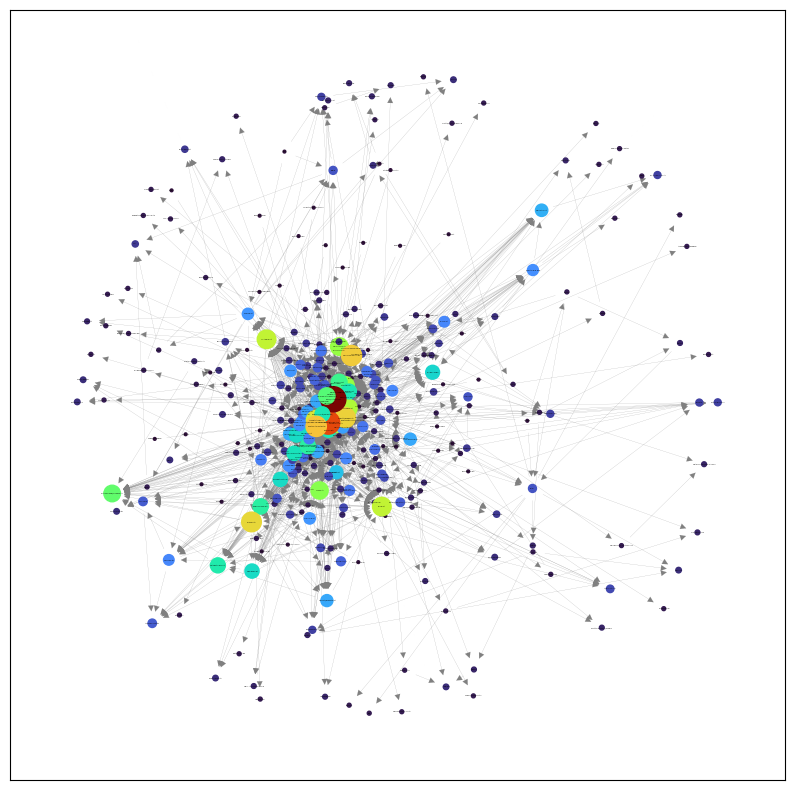

[('Abilene Regional', '0.01'),
 ('Adak Naf', '0.02'),
 ('Adams Field', '0.03'),
 ('Akiachak', '0.01'),
 ('Akiak', '0.01'),
 ('Akron-Canton Regional', '0.02'),
 ('Albany County', '0.01'),
 ('Albert J Ellis', '0.01'),
 ('Albuquerque Intl', '0.05'),
 ('Alexander Hamilton', '0.04')]

In [69]:
def eigenvector_centrality(grph, max_iter=100, tol=1e-01, nstart=None, weight=None):
    return nx.eigenvector_centrality(grph,  max_iter=max_iter, tol=tol, nstart=nstart, weight=weight)

centrality  = eigenvector_centrality(G1_net, max_iter=100, tol=1e-01, nstart=None, weight=None)
centrality_function(eigenvector_centrality, G1_net)

sorted((v, f"{c:0.2f}") for v, c in centrality.items())[0:10]

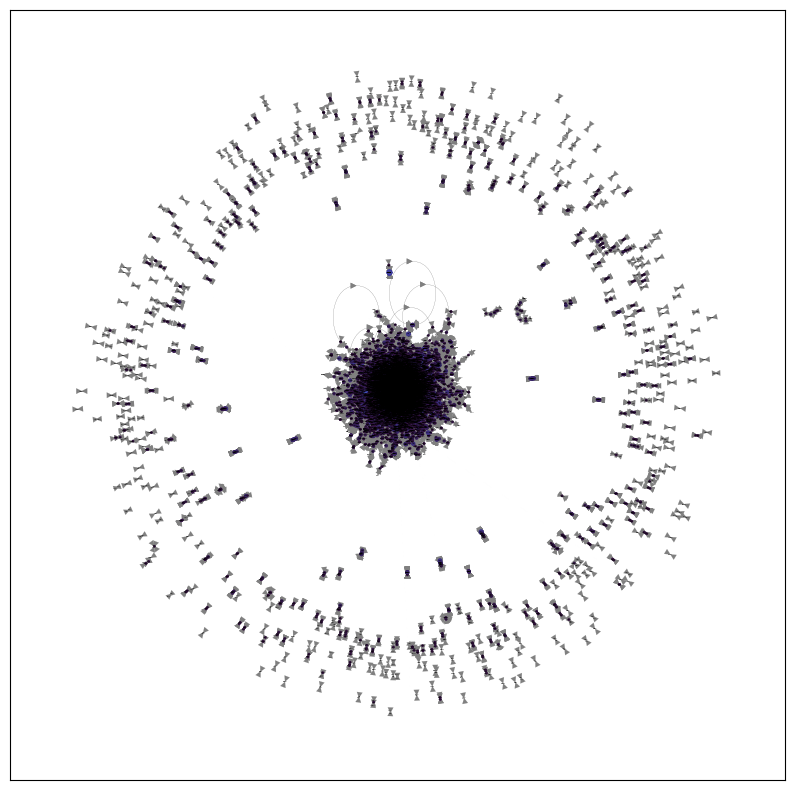

[('0', '0.00'),
 ('1', '0.00'),
 ('10', '0.00'),
 ('100', '0.01'),
 ('1000', '0.00'),
 ('10000', '0.01'),
 ('10001', '0.01'),
 ('10002', '0.00'),
 ('10003', '0.01'),
 ('10004', '0.00')]

In [70]:
def eigenvector_centrality(grph, max_iter=100, tol=1e-01, nstart=None, weight=None):
    return nx.eigenvector_centrality(grph,  max_iter=max_iter, tol=tol, nstart=nstart, weight=weight)

centrality  = eigenvector_centrality(G2_edgl, max_iter=100, tol=1e-01, nstart=None, weight=None)
centrality_function(eigenvector_centrality, G2_edgl)

sorted((v, f"{c:0.2f}") for v, c in centrality.items())[0:10]

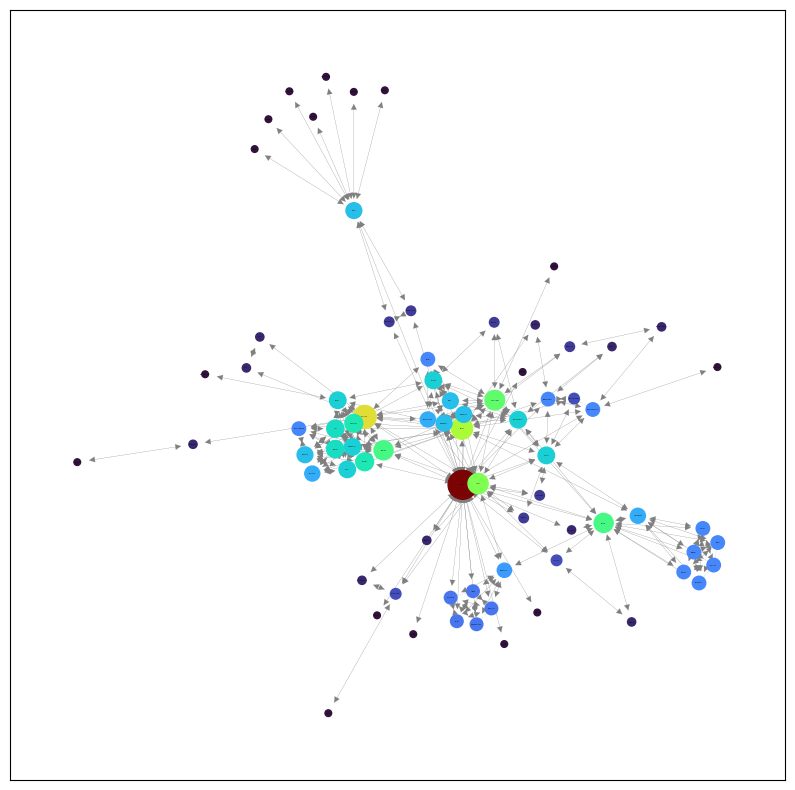

[('Anzelma', '0.05'),
 ('Babet', '0.13'),
 ('Bahorel', '0.15'),
 ('Bamatabois', '0.11'),
 ('BaronessT', '0.04'),
 ('Blacheville', '0.09'),
 ('Bossuet', '0.16'),
 ('Boulatruelle', '0.02'),
 ('Brevet', '0.08'),
 ('Brujon', '0.09')]

In [45]:
def eigenvector_centrality(grph, max_iter=100, tol=1e-01, nstart=None, weight=None):
    return nx.eigenvector_centrality(grph,  max_iter=max_iter, tol=tol, nstart=nstart, weight=weight)

centrality  = eigenvector_centrality(G3_gml, max_iter=100, tol=1e-01, nstart=None, weight=None)
centrality_function(eigenvector_centrality, G3_gml)

sorted((v, f"{c:0.2f}") for v, c in centrality.items())[0:10]

  4. **Katz**
  
   - Katz centrality computes the centrality for a node based on the centrality of its neighbors. 
   - It is a generalization of the eigenvector centrality. The Katz centrality for node is :
      - $\large x_i = \alpha \sum_{j} A_{ij} x_j + \beta,$
         - where is the adjacency matrix of graph $G$ with eigenvalues $\lambda$.
         - The parameter controls the initial centrality and $\large \alpha < \frac{1}{\lambda_{\max}}.$



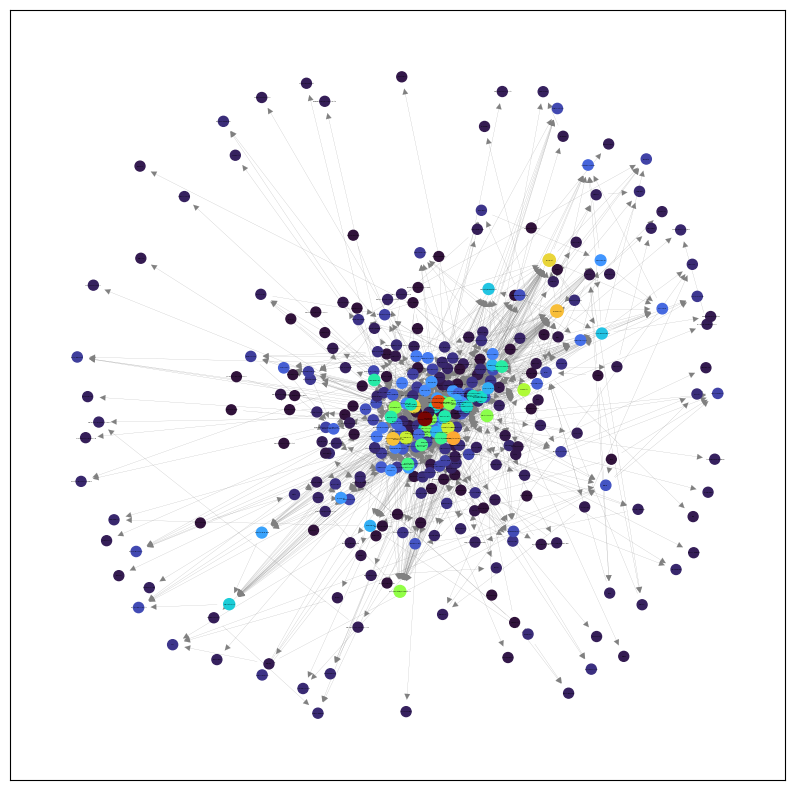

[('Wiley Post-Will Rogers Mem', 0.050579646319607395),
 ('Deadhorse', 0.05108544278280347),
 ('Ralph Wien Memorial', 0.050579646319607395),
 ('Fairbanks Intl', 0.051596297210631505),
 ('Nome', 0.05108544278280347),
 ("St Mary's", 0.050579646319607395),
 ('Aniak', 0.05108544278280347),
 ('Anchorage Intl', 0.05414556196478603),
 ('Tuluksak', 0.050579646319607395),
 ('Akiachak', 0.05108544278280347)]

In [46]:
def katz_centrality(grph, max_iter=1500, weight='weight', tol=1e-3):
    # Calculate the largest eigenvalue
    largest_eigenvalue = max(np.linalg.eigvals(nx.adjacency_matrix(grph).todense()))
    # Set alpha to be less than 1/largest_eigenvalue
    # alpha = 1 / largest_eigenvalue * 0.9  # Adjust factor as needed
    # Compute Katz centrality using numpy implementation
    return nx.katz_centrality(grph, max_iter=max_iter, alpha=0.01,tol=tol, weight=' weight')

k_centrality = katz_centrality(G1_net, max_iter=1500, weight='weight', tol=1e-3)
centrality_function(katz_centrality, G1_net)
# centralité de Katz#
list(k_centrality.items())[:10]

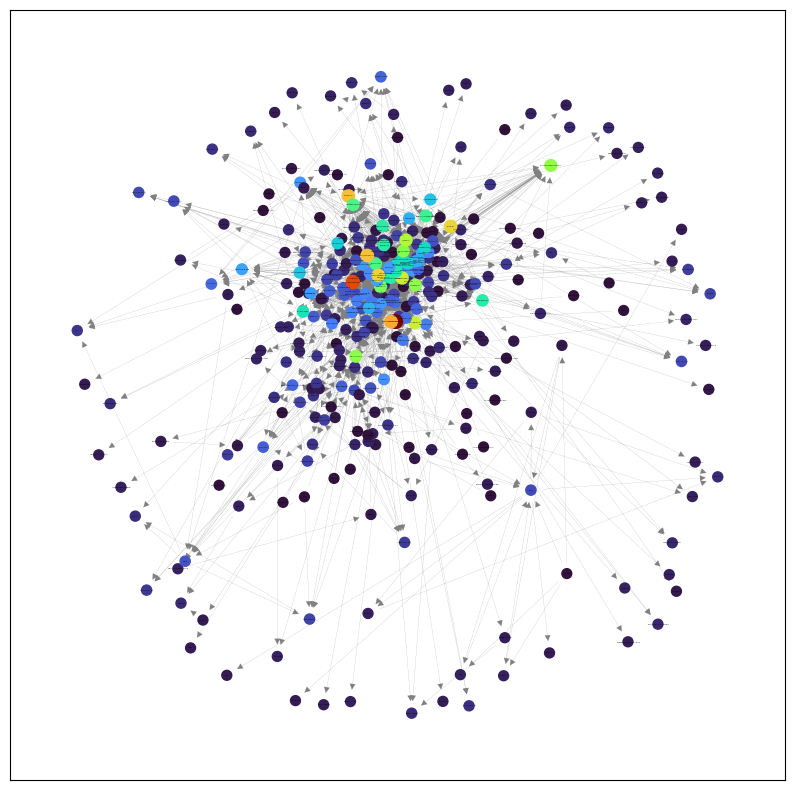

[('Wiley Post-Will Rogers Mem', 0.050579646319607395),
 ('Deadhorse', 0.05108544278280347),
 ('Ralph Wien Memorial', 0.050579646319607395),
 ('Fairbanks Intl', 0.051596297210631505),
 ('Nome', 0.05108544278280347),
 ("St Mary's", 0.050579646319607395),
 ('Aniak', 0.05108544278280347),
 ('Anchorage Intl', 0.05414556196478603),
 ('Tuluksak', 0.050579646319607395),
 ('Akiachak', 0.05108544278280347)]

In [47]:
k_centrality = katz_centrality(G2_edgl, max_iter=1500, weight='weight', tol=1e-3)
centrality_function(katz_centrality, G2_edgl)
# centralité de Katz#
list(k_centrality.items())[:10]

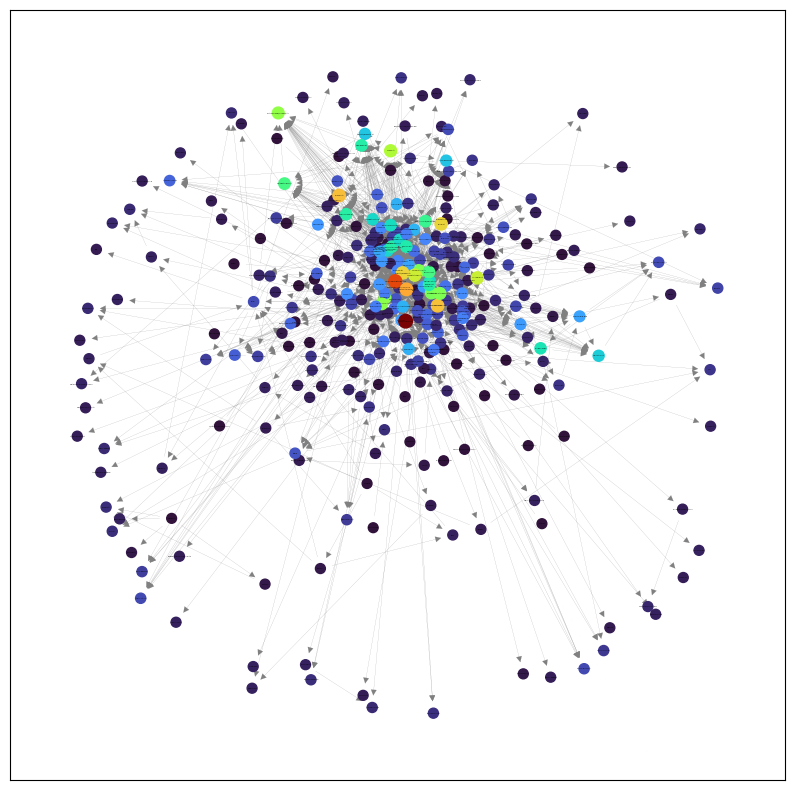

[('Wiley Post-Will Rogers Mem', 0.050579646319607395),
 ('Deadhorse', 0.05108544278280347),
 ('Ralph Wien Memorial', 0.050579646319607395),
 ('Fairbanks Intl', 0.051596297210631505),
 ('Nome', 0.05108544278280347),
 ("St Mary's", 0.050579646319607395),
 ('Aniak', 0.05108544278280347),
 ('Anchorage Intl', 0.05414556196478603),
 ('Tuluksak', 0.050579646319607395),
 ('Akiachak', 0.05108544278280347)]

In [48]:
k_centrality = katz_centrality(G3_gml, max_iter=1500, weight='weight', tol=1e-3)
centrality_function(katz_centrality, G3_gml)
# centralité de Katz#
list(k_centrality.items())[:10]

  5. **betweenness**   
  - Compute the shortest-path betweenness centrality for nodes. 
  - Betweenness centrality of a node is the sum of the fraction of all-pairs shortest paths that pass through $v$ 
   
     - $\large c_B(v) =\sum_{s,t \in V} \frac{\sigma(s, t|v)}{\sigma(s, t)}$

  - where $v$ is the set of nodes, $\sigma(s,t)$ is the number of shortest $(s,t)$ -paths, and $\sigma(s,t|v)$ is the number of those paths passing through some node other than 
. If $s=t$, $\sigma(s,t)=1$, and if $v \in s, t, \sigma(s,t)=0$.

 

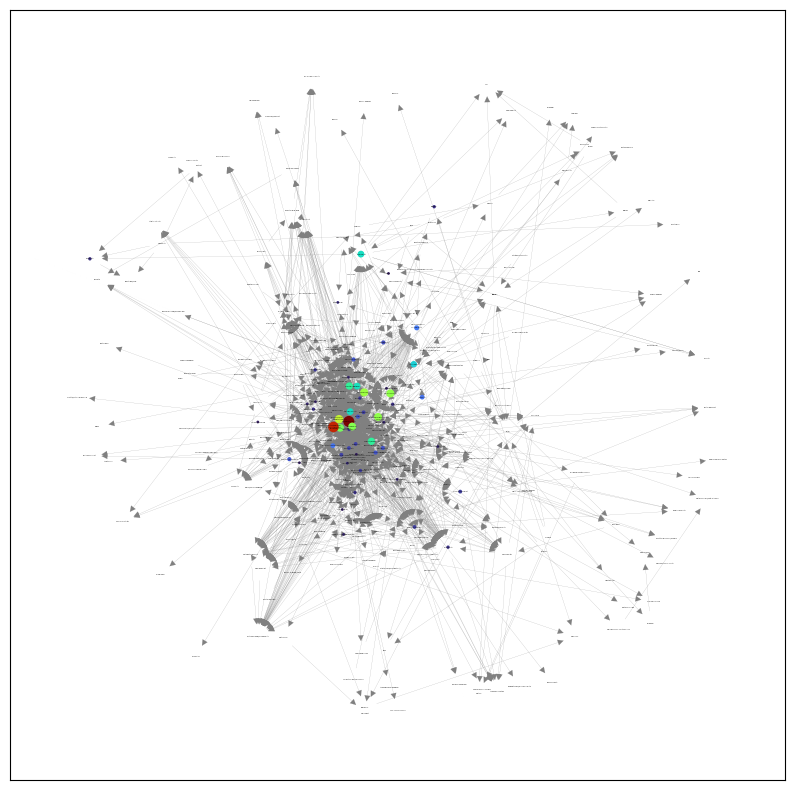

['Wiley Post-Will Rogers Mem',
 'Deadhorse',
 'Ralph Wien Memorial',
 'Fairbanks Intl',
 'Nome',
 "St Mary's",
 'Aniak',
 'Anchorage Intl',
 'Tuluksak',
 'Akiachak']

In [71]:
def betweenness_centrality(grph):
    return nx.betweenness_centrality(grph)

centrality_function(betweenness_centrality, G1_net)
# intermédiarité
list(nx.betweenness_centrality(G1_net))[:10]

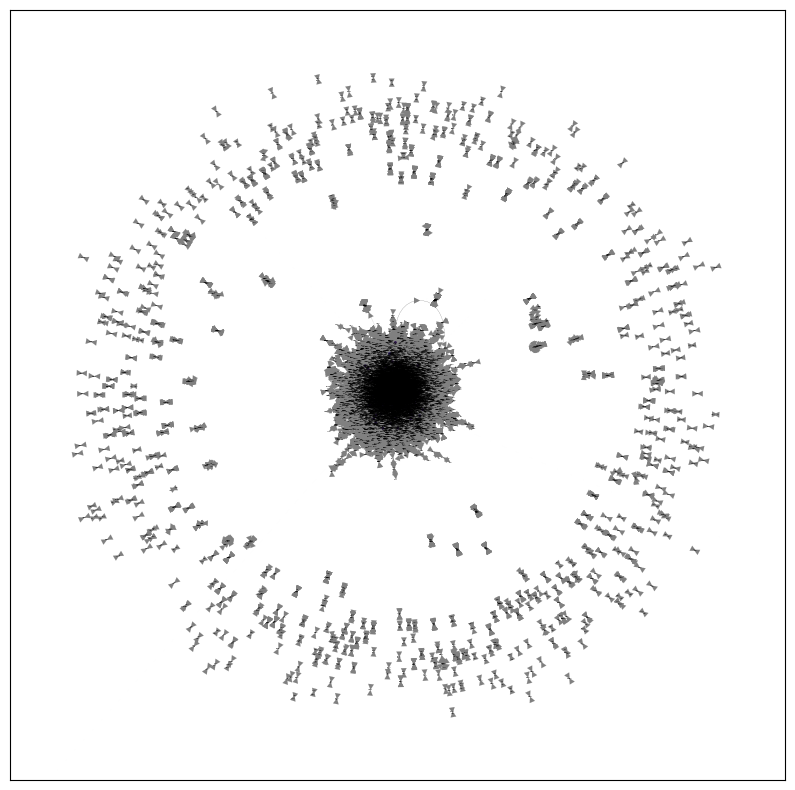

['0', '1680', '6918', '19642', '1820', '2438', '10014', '15750', '16763', '1']

In [51]:
centrality_function(betweenness_centrality, G2_edgl)
# intermédiarité
list(nx.betweenness_centrality(G2_edgl))[:10]

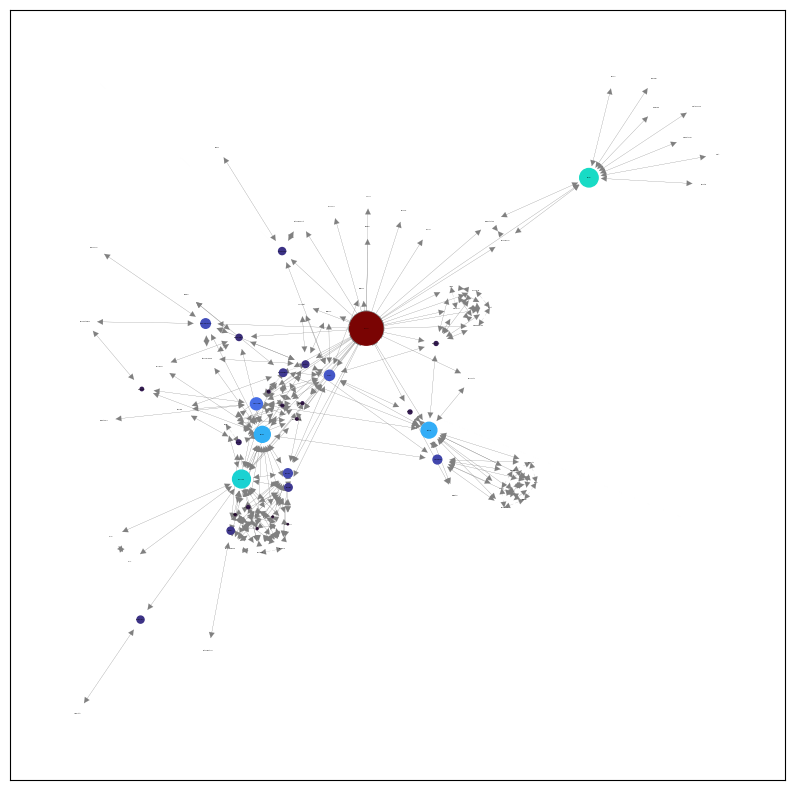

['Myriel',
 'Napoleon',
 'MlleBaptistine',
 'MmeMagloire',
 'CountessDeLo',
 'Geborand',
 'Champtercier',
 'Cravatte',
 'Count',
 'OldMan']

In [72]:
centrality_function(betweenness_centrality, G3_gml)
# intermédiarité
list(nx.betweenness_centrality(G3_gml))[:10]

## Page Rank and HITS
Similarly to the previous question, have a look to the package documentation and calculate the following metrics:

### **Page Rank**

 - **Matrix formulation**

   - Extension to a random surfer mode, compute the pagerank of node as the probability that a random surfer starts at a random node and ends at node p.
   - The PageRank algorithm can be formulated using a matrix representation, which is more efficient for large graphs.

      $\large PR(i) = \alpha * \sum_{j \in in(i)} \frac{PR(j)}{d_{j}^{out}} + (1 - \alpha) * \frac{1}{N}$

      Here, you could interpret:

      - $C_p(i)$ as a score or value for node $i$   
      - $A_{ij}$ as an element of the adjacency matrix (1 if there is a link from $j$ to $i$, 0 otherwise)   
      - $d_{j}^{out}$ as the number of outgoing links from node    
      - $\alpha$ and $\beta$ as parameters similar to the damping factor and the teleportation factor in PageRank  
      - $N$ is the total number of nodes. 
    
 - **Convergence**: 

    - La fonction vérifie si la différence entre les scores de PageRank des itérations consécutives est inférieure à une certaine tolérance (tol). 
    - Si c'est le cas, elle arrête l'itération.
    - La fonction retourne un dictionnaire pagerank_values où chaque clé est un noeud du graphe et la valeur correspondante est le score de PageRank calculé

  - **Step 1: Construction of the Adjacency Matrix `A`**
    - The adjacency matrix A of the graph. In this matrix, $A_{ij} = 1$ if there is a link from node $j$ to node $i$, and $A_{ij} = 0$ otherwise.
  - **Step 2: Normalization of the Adjacency Matrix to Get `S`**  
    - To make the matrix stochastic, we need to normalize the columns of A. 
    - This involves dividing each element in a column by the sum of the elements, which represents the number of outgoing links from each node. 
  - **Step 3: Construction of the Teleportation Matrix** 
    - The teleportation matrix is a matrix where each element is 1/N, representing the probability of a random surfer teleporting to any node with equal probability.  
   - **Step 4: Combining S and E with the Damping Factor $\alpha$**  
       - Initialize the n-dimension vector $PR^0 = (1/n, ...1/n)$ 
       - $PR^{t+1} = W^T @ PR^t$
            - $W^t$ The transposed transition matrix of graph G
            - $PR^{t+1}$ The n-dimensionnal PageRank vector at step t+1
            - $PR^t$ The n-dimensionnal PageRank vector at step t
       - Extension to a random surfer model      
         - $\large PR^{t+1} = \alpha  W^T @ PR^t + (1 - \alpha) \frac{1}{N}$
  
             


In [74]:
def get_google_matrix(G, alpha=0.85):
    n = G.number_of_nodes()
    # Create an adjacency matrix
    A = nx.to_numpy_array(G, dtype=np.float64).T  # Transpose to get the correct direction
    is_sink = np.sum(A, axis=0) == 0
    #print(f'is_sink : {is_sink}')
    B = (np.ones_like(A) - np.identity(n)) / (n - 1)
    #print(f'B : {B}')
    A[:, is_sink] += B[:, is_sink]
    #print(f'A : {A}')
    D_inv = np.diag(1 / np.sum(A, axis=0))
    #print(f'D_inv : {D_inv}')
    S = np.dot(A, D_inv)
    #print(f'S : {S}')
    E = np.ones((n, n)) / n
    #print(f'E : {E}')
    G = alpha * S + (1 - alpha) * E
    return G

def pagerank_matrix(G, alpha=0.85, max_iter=100, tol=1e-06):
    n = G.number_of_nodes()
    G_matrix = get_google_matrix(G, alpha)
    v = np.ones(n) / n  # Initial PageRank vector
    for i in range(max_iter):
        new_v = G_matrix @ v
        if np.linalg.norm(new_v - v) < tol:
            break
        v = new_v
    #print(f'----------{i}------------')    
    return v

In [75]:
# Calculate PageRank using the matrix method
pagerank_values = pagerank_matrix(G1_net)
# Print the results
for i, node in enumerate(G1_net.nodes):
    if i > 10 :
        break
    print(f"Node {node}: {pagerank_values[i]}")

Node Wiley Post-Will Rogers Mem: 0.000912412576053391
Node Deadhorse: 0.0010641138146893062
Node Ralph Wien Memorial: 0.000912412576053391
Node Fairbanks Intl: 0.0015165863219851927
Node Nome: 0.0011000243970291793
Node St Mary's: 0.000912412576053391
Node Aniak: 0.001061761912868866
Node Anchorage Intl: 0.004717501804586586
Node Tuluksak: 0.000912412576053391
Node Akiachak: 0.0010762622631509432
Node Akiak: 0.0012612757758462215


In [76]:
# Calculate PageRank using the matrix method
pagerank_values = pagerank_matrix(G2_edgl)
# Print the results
for i, node in enumerate(G2_edgl.nodes):
    if i > 10 :
        break
    print(f"Node {node}: {pagerank_values[i]}")

Node 0: 2.2694643565626043e-05
Node 1680: 4.646081197458132e-05
Node 6918: 3.315875674130784e-05
Node 19642: 3.3158756741307824e-05
Node 1820: 2.9880585672786258e-05
Node 2438: 0.00010349422158645693
Node 10014: 2.9880585672786244e-05
Node 15750: 2.6693285792306663e-05
Node 16763: 0.00023847499799485916
Node 1: 2.815987444833048e-05
Node 4131: 6.41064141056168e-05


In [77]:
# Calculate PageRank using the matrix method
pagerank_values = pagerank_matrix(G3_gml)
# Print the results
for i, node in enumerate(G3_gml.nodes):
    if i > 10 :
        break
    print(f"Node {node}: {pagerank_values[i]}")

Node Myriel: 0.042779648322842596
Node Napoleon: 0.00558441762454819
Node MlleBaptistine: 0.010277309178962694
Node MmeMagloire: 0.010277309178962694
Node CountessDeLo: 0.00558441762454819
Node Geborand: 0.00558441762454819
Node Champtercier: 0.00558441762454819
Node Cravatte: 0.00558441762454819
Node Count: 0.00558441762454819
Node OldMan: 0.00558441762454819
Node Labarre: 0.00372904810116642


In [81]:
import networkx as nx
import numpy as np

#G=G1_net
#G=G2_edgl
G=G3_gml
# Get the number of nodes
n = G.number_of_nodes() 
# Create an adjacency matrix
A = nx.to_numpy_array(G, dtype=np.float64)
# Identify dangling nodes
dangling_nodes = [node for node in G.nodes if G.out_degree(node) == 0]
# Create a vector to distribute probability from dangling nodes
dangling_vector = np.zeros(n)

#if dangling_nodes:
 #   dangling_vector[:] = 1 / n

# Normalize the adjacency matrix
M = A / A.sum(axis=1, keepdims=True)

# Handle dangling nodes
for i in range(n):
    if A.sum(axis=1)[i] == 0:
        M[i] = dangling_vector

# Damping factor
alpha = 0.85
# Personalization vector (uniform distribution by default)
personalization = np.ones(n) / n
# Google matrix
GM = alpha * M + (1 - alpha) * personalization[:, np.newaxis]
# Initial PageRank vector
pr = np.ones(n) / n

# Maximum number of iterations and tolerance
max_iter = 100
tol = 1e-6

for _ in range(max_iter):
    new_pr = GM.T @ pr
    if np.linalg.norm(new_pr - pr) < tol:
        break
    pr = new_pr

pr = pr / pr.sum()  # Normalize the PageRank vector

# Display the PageRank values
for node, rank in enumerate(pr):
    if node > 10 : 
        break
    print(f"Node {node}: {rank:.4f}")

Node 0: 0.0428
Node 1: 0.0056
Node 2: 0.0103
Node 3: 0.0103
Node 4: 0.0056
Node 5: 0.0056
Node 6: 0.0056
Node 7: 0.0056
Node 8: 0.0056
Node 9: 0.0056
Node 10: 0.0037


### **Hub and Authorities (HITS)**

- **Authorities**: 
  - These are web pages that are considered to be authoritative on a particular topic. 
  - An authority score is assigned to each page, which reflects the value of the content on that page. 
  - A page is considered a good authority if many high-quality hubs link to it.
  - Authorities estimates the node value based on the incoming links. 

- **Hubs**: 
  - These are web pages that serve as directories or compilations of links to other authoritative pages. 
  - A hub score is assigned to each page, indicating the value of its outgoing links. 
  - A page is considered a good hub if it links to many high-quality authorities.
  - Hubs estimates the node value based on outgoing links. 
  

- **The HITS algorithm computes two numbers for a node**. 




In [94]:
def display_hub_autorities(G):
    # Compute hub and authority scores
    hubs, authorities = nx.hits(G, max_iter=100, normalized=True)
    # Prepare node labels
    node_labels = {node: f"{node}\nHub: {hubs[node]:.2f}\nAuth: {authorities[node]:.2f}" for node in G.nodes}
    # Prepare node colors and sizes based on scores
    # Create a colormap
    cmap = mpl.colormaps['turbo']
    node_colors = [hubs[node] for node in G.nodes]
    node_sizes = [authorities[node] * 3500 for node in G.nodes]
    # Position the nodes
    plt.figure(figsize=(10, 10))
    pos = nx.spring_layout(G)
    # Draw the graph
    nx.draw_networkx_edges(G, pos, width=0.1, edge_color='gray')
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=1)
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, cmap=cmap, node_size=node_sizes)
    plt.axis('off')  # Turn off axis
    plt.show()

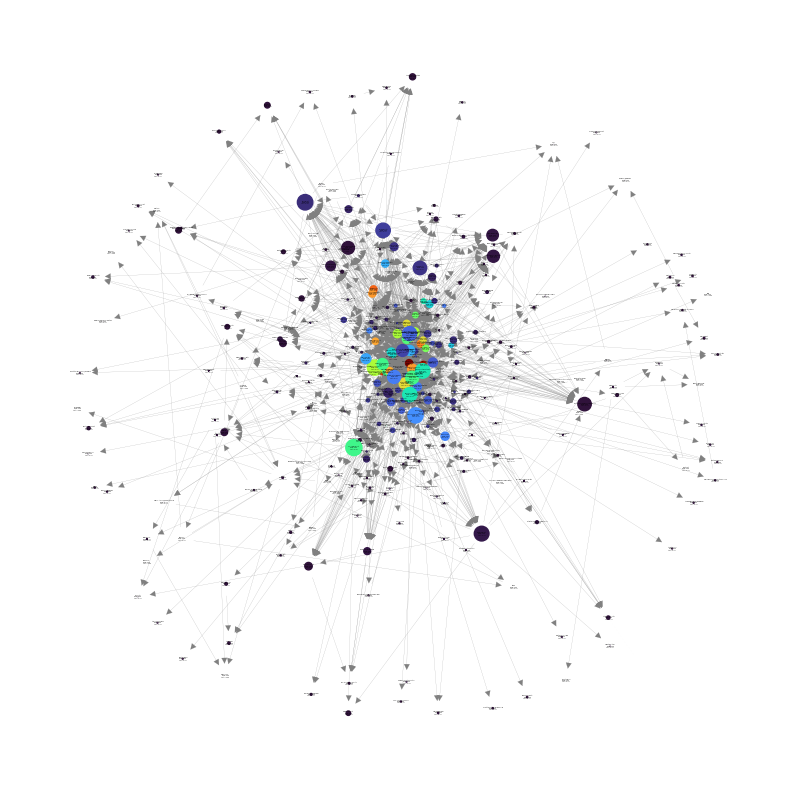

In [95]:
display_hub_autorities(G1_net)

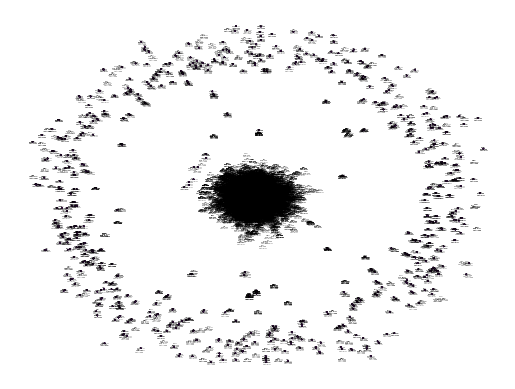

In [86]:
display_hub_autorities(G2_edgl)

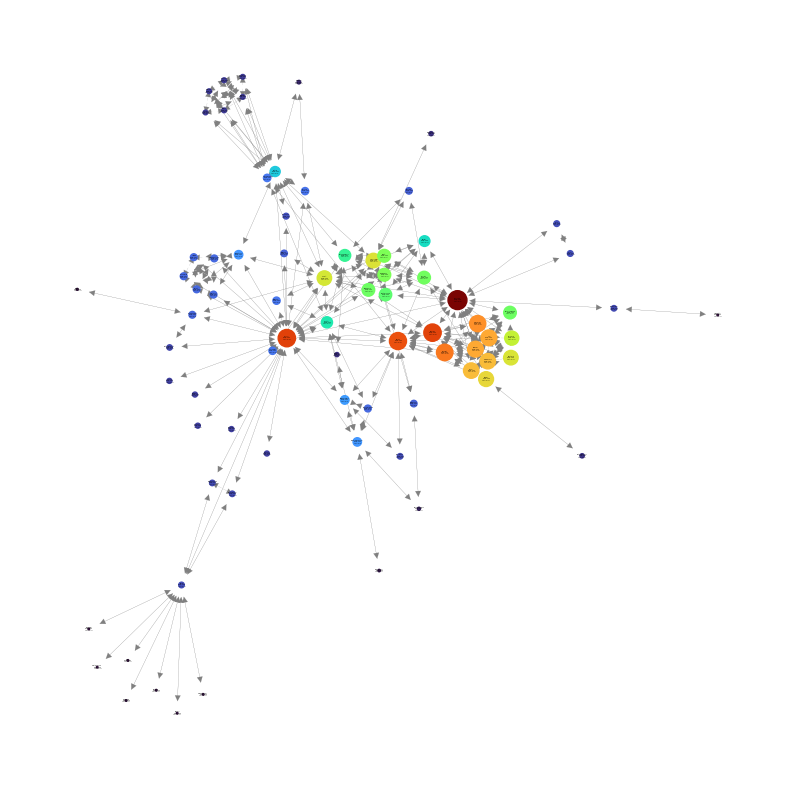

In [96]:
display_hub_autorities(G3_gml)

## On the correlation of node-centric metrics
First, create a dataframe using with the above calculated centralities.

In [97]:
GD = G1_net
#GD = G2_edgl
#GD = G3_gml

# intermédiarité
betweenness_centrality = nx.betweenness_centrality(GD)
pdf1 = pd.DataFrame(list(betweenness_centrality.items()), columns=['ID', 'betweenness'])
# centralité de Katz
katz_centrality = nx.katz_centrality(GD)
pdf2 = pd.DataFrame(list(katz_centrality.items()), columns=['ID', 'katz'])
# proximité
closeness_centrality = nx.closeness_centrality(GD)
pdf3 = pd.DataFrame(list(closeness_centrality.items()), columns=['ID', 'closeness'])
# Calculate degree centrality
degree_centrality = nx.degree_centrality(GD)
pdf4 = pd.DataFrame(list(degree_centrality.items()), columns=['ID', 'degree'])

# Combinez les listes de tuples en utilisant zip
df = pd.merge(pdf1, pdf2, on='ID')
df = pd.merge(df,   pdf3, on='ID')
df = pd.merge(df,   pdf4, on='ID')

df.head(10).style

,ID,betweenness,katz,closeness,degree
0,Wiley Post-Will Rogers Mem,0.000000,0.002943,0.000000,0.009063
1,Deadhorse,0.000000,0.003237,0.003021,0.009063
2,Ralph Wien Memorial,0.000000,0.002943,0.000000,0.006042
3,Fairbanks Intl,0.000412,0.003561,0.006042,0.015106
4,Nome,0.000000,0.003237,0.003021,0.006042
5,St Mary's,0.000000,0.002943,0.000000,0.009063
6,Aniak,0.000000,0.003237,0.003021,0.009063
7,Anchorage Intl,0.013871,0.005153,0.021148,0.087613
8,Tuluksak,0.000000,0.002943,0.000000,0.012085
9,Akiachak,0.000000,0.003237,0.003021,0.012085


Then, we will plot the pairwise relationships between centralities to have a first glimpse of the possible correlation between them. For this, use the `pairplot` function of the `seaborn` package.

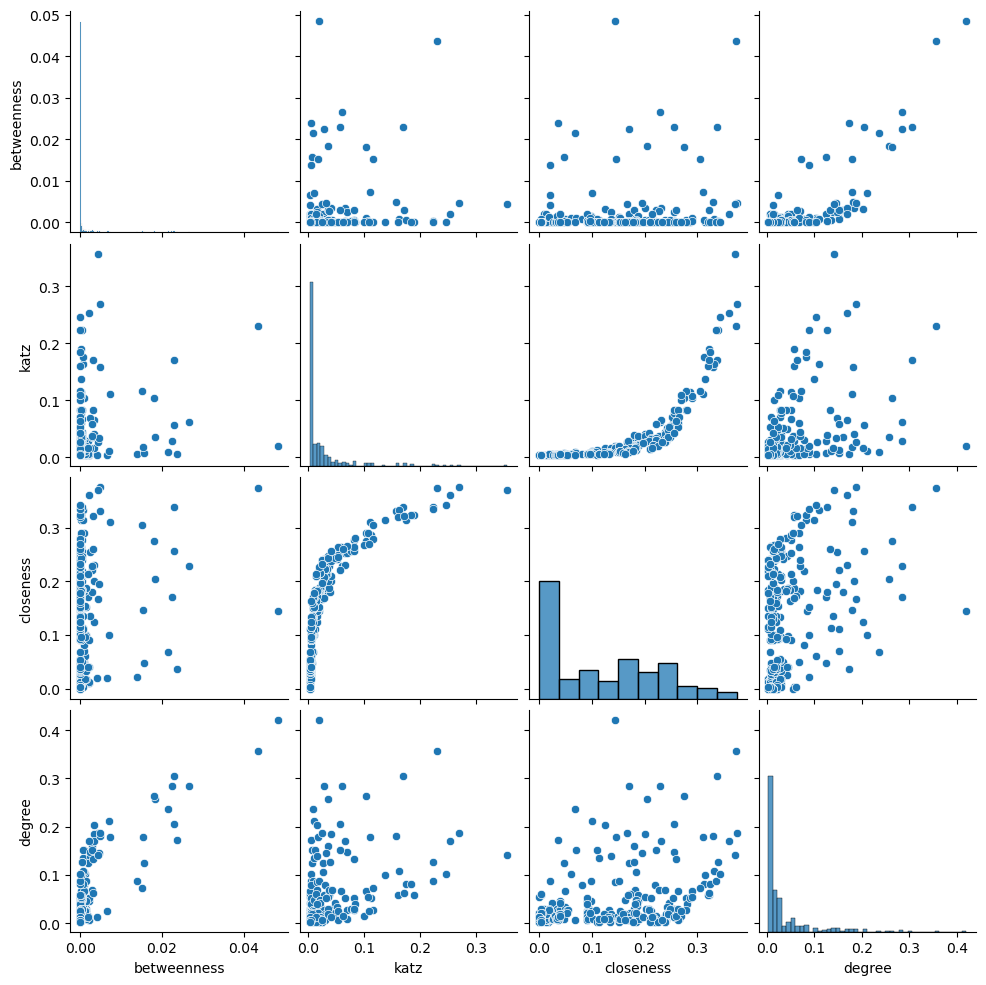

In [98]:
# Create the pairplot
sns.pairplot(df)
plt.show()

<table>
<tr>
<th style="padding: 4px; border: 1px solid #ddd;">Centrality </th>
<th style="padding: 4px; border: 1px solid #ddd;">Low degree</th>
<th style="padding: 4px; border: 1px solid #ddd;">Low closeness</th>
<th style="padding: 4px; border: 1px solid #ddd;">Low betweeness</th>
</tr>

<tr>
<td style="padding: 4px; border: 1px solid #ddd;">High degree</td>
<td style="padding: 4px; border: 1px solid #ddd; word-wrap: break-word;"> </td>
<td style="padding: 4px; border: 1px solid #ddd; word-wrap: break-word;">Embedded in cluster that is far from the rest of network</td>
<td style="padding: 4px; border: 1px solid #ddd; word-wrap: break-word;">Ego's connection are redudant communication bypasses him-her</td>
</tr>

<tr>
<td style="padding: 4px; border: 1px solid #ddd;">High closeness</td>
<td style="padding: 4px; border: 1px solid #ddd; word-wrap: break-word;">Key player tied to important/active players</td>
<td style="padding: 4px; border: 1px solid #ddd; word-wrap: break-word;"> </td>
<td style="padding: 4px; border: 1px solid #ddd; word-wrap: break-word;">Probably multiple path in the network ego is near many people, but so are many others</td>
</tr>

<tr>
<td style="padding: 4px; border: 1px solid #ddd;">High betweeness</td>
<td style="padding: 4px; border: 1px solid #ddd; word-wrap: break-word;">Egos's few tied are crucial for network flow</td>
<td style="padding: 4px; border: 1px solid #ddd; word-wrap: break-word;">Many rare cells. Would know that ego monopolisizes the tied for a small number of people to many others</td>
<td style="padding: 4px; border: 1px solid #ddd; word-wrap: break-word;"></td>
</tr>
</table>

 - We will now assess more properly these potential correlations.    
 - For this, use the `corr()` on your data frame. Be aware that the default method mignt not be appropriate to your case. 
 - Once the pairwise correlations have been calculated, we will plot the related method using the `heatmap()` function of the `seaborn` package. 
 
    - TIP: to change the color scheme, you can use the `cmap` parameter with value `plt.get_cmap(xxx)` where `xxx` is a color scheme (visit [this site](https://matplotlib.org/users/colormaps.html) to get the list of existing cholor schemes).

             betweenness      katz  closeness    degree
betweenness     1.000000  0.344593   0.271376  0.668236
katz            0.344593  1.000000   0.893605  0.412663
closeness       0.271376  0.893605   1.000000  0.335165
degree          0.668236  0.412663   0.335165  1.000000


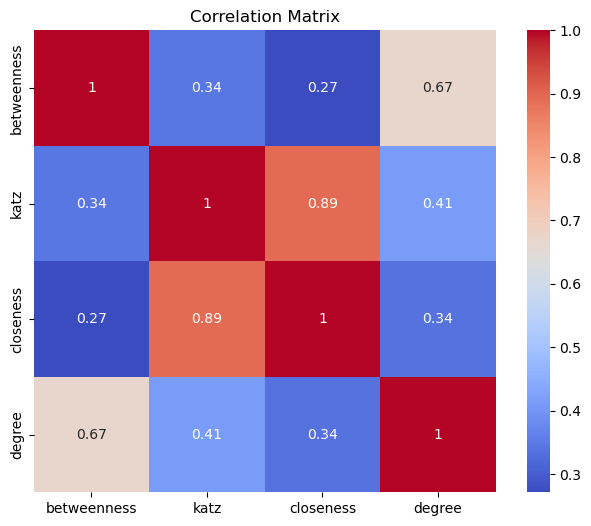

In [99]:
# Calculate pairwise correlations using Pearson method (default)
# Select all columns except 'B'
df_excluded = df.loc[:, df.columns != 'ID']
correlation_matrix = df_excluded.corr(method='kendall')
print(correlation_matrix)
# Plot the correlation matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.show()

**Matrix Interpretation**

 - **Diagonal Value**: These are all 1.000000, indicating perfect correlation of each measure with itself, as expected.

 - **Off-Diagonal Value**: These represent the correlation between different centrality measures. Values range from -1 to 1, where:
    - 1 indicates a perfect positive correlation.
    - 0 indicates no correlation.
    - -1 indicates a perfect negative correlation.

**Specific Interpretations**
 - **Betweenness and Degree (0.668236)**: There is a moderate positive correlation, suggesting that nodes with high betweenness centrality also tend to have high degree centrality.

 - **Katz and Closeness (0.893605)**: There is a strong positive correlation, indicating that nodes with high Katz centrality often have high closeness centrality.

 - **Betweenness and Katz (0.344593)**: A low to moderate positive correlation, suggesting some relationship but not very strong.

 - **Betweenness and Closeness (0.271376)**: A low positive correlation, indicating a weak relationship between these measures.

 - **Katz and Degree (0.412663)**: A moderate positive correlation, showing some relationship between these measures.

 - **Closeness and Degree (0.335165)**: A low to moderate positive correlation, suggesting some nodes with high closeness also have high degree.
 
**Conclusion**
The matrix provides insights into how different centrality measures relate to each other in the network. Strong correlations can indicate redundancy or similar roles in identifying important nodes, while weak correlations suggest that the measures capture different aspects of node importance.

On the finding of atypical vertices
------------------------------------

 - As discussed during the lecture ans as you have just seen in the previous question, centrality metrics are often positively correlated. 
    - We will now find some key vertices in the network.
    - Typically, these vertices are vertices that somehow "break" the positive pairwise correlations. 
    
 - You mission is to find at least one of these vertices. 
 - To do so, you will apply the following methodology:
   1. Extract the 10 top airports per centrality metric
   2. Compare the list and conclude


In [102]:
G = G1_net
#G = G2_edgl
#G = G3_gml
# Calculate centrality metrics
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
closeness_centrality = nx.closeness_centrality(G)

# Convert centrality metrics to DataFrames
df_degree = pd.DataFrame(list(degree_centrality.items()), columns=['Airport', 'Degree Centrality'])
df_betweenness = pd.DataFrame(list(betweenness_centrality.items()), columns=['Airport', 'Betweenness Centrality'])
df_closeness = pd.DataFrame(list(closeness_centrality.items()), columns=['Airport', 'Closeness Centrality'])

# Sort and extract the top 10 airports for each centrality metric
top_10_degree = df_degree.nlargest(10, 'Degree Centrality')
top_10_betweenness = df_betweenness.nlargest(10, 'Betweenness Centrality')
top_10_closeness = df_closeness.nlargest(10, 'Closeness Centrality')

# Extract the airport names from each list
degree_airports = set(top_10_degree['Airport'])
betweenness_airports = set(top_10_betweenness['Airport'])
closeness_airports = set(top_10_closeness['Airport'])

# Find airports that are not consistently in the top 10 across all metrics
atypical_airports = (degree_airports | betweenness_airports | closeness_airports) - (degree_airports & betweenness_airports & closeness_airports)

print("Atypical Airports:", atypical_airports)

Atypical Airports: {'Detroit Metropolitan Wayne Cou', 'Stapleton Intl', 'Lambert-St Louis Intl', 'Phoenix Sky Harbor Intl', 'Houston Intercontinental', 'Charlotte/Douglas Intl', 'San Diego Intl-Lindbergh Fld', 'Tampa Intl', 'Orlando Intl', 'Minneapolis-St Paul Intl/Wold-', "Chicago O'hare Intl", 'Southwest Florida Intl', 'Seattle-Tacoma Intl', 'Miami Intl', 'Fort Lauderdale/Hollywood Intl', 'Pittsburgh Intll', 'San Francisco Intl'}


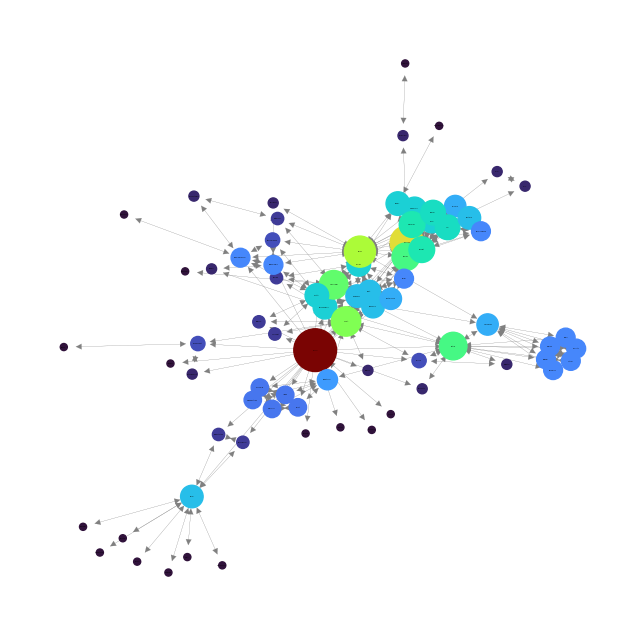

In [105]:
G=G3_gml
# Calculate centrality metrics
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
closeness_centrality = nx.closeness_centrality(G)

# Define the positions of the vertices
positions = {
    'A': (0, 0),
    'B': (1, 0),
    'C': (0.5, 1),
    'D': (1.5, 1),
    'E': (2, 0),
    'F': (2.5, 1),
    'G': (0, -1),
    'H': (1.5, -1)
}

# Generate positions using spring layout
plt.figure(figsize=(8, 8))
pos = nx.spring_layout(G)
min_degree = min(degree_centrality.values())
max_degree = max(degree_centrality.values())
norm = mpl.colors.Normalize(vmin=min_degree, vmax=max_degree)
# Create a colormap
cmap = mpl.colormaps['turbo']
node_sizes = [int(degree * 1000) for degree in degree_centrality.values()]
node_colors = [cmap(norm(degree)) for degree in degree_centrality.values()]

# Draw the graph
nx.draw_networkx_nodes(G2, pos, node_color=node_colors, node_size=node_sizes)
nx.draw_networkx_edges(G2, pos, width=0.1, edge_color='gray')
nx.draw_networkx_labels(G2, pos, font_size=1)

plt.axis('off')  # Turn off axis
plt.show()